# Exploratory Data Analysis (EDA) - Telco Customer Churn

Este notebook é destinado à etapa de EDA conforme definido no `docs/ml_canvas.md`.

## Objetivos da EDA:
- Analisar dados demográficos, serviços assinados e informações contratuais.
- Investigar as features e realizar as devidas limpezas de dados.
- Avaliar as Abordagens A e B propostas (One-Hot Encoding vs Normalização/Escalonamento).
- Definir potenciais tratamentos de outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Carregamento dos Dados
**Fonte**: Dataset IBM Telco Customer Churn.
*(O arquivo deve estar disponível no diretório `data/raw` ou semelhante)*

In [2]:
# Exemplo de carregamento:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Sanidade de Tipos

Nesta etapa, vamos garantir que os tipos de dados estão corretos e tratar valores ausentes iniciais.

In [3]:
# 1. Converter TotalCharges para numérico (valores vazios ' ' se tornarão NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Verificar NaNs e tratar
nan_count = df['TotalCharges'].isna().sum()
print(f"Valores nulos em TotalCharges: {nan_count}")

# Justificativa da Remoção: Como são apenas 11 registros (representando clientes recém-chegados com tenure=0),
# e não possuem histórico de cobrança ainda, a remoção é segura e não afeta a distribuição geral do dataset.
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Remover a coluna customerID, pois é apenas um identificador único sem poder preditivo
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

df.info()

Valores nulos em TotalCharges: 11
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 n

## 3. Análise de Desbalanceamento (Alvo e Histórico)

Conforme indicado no ML Canvas, precisamos entender o desbalanceamento das classes para justificar a necessidade de abordagens robustas (como métricas F1-Score ou reamostragem).
Aqui avaliamos a distribuição de `Churn` e do tempo de casa do cliente (`tenure`).

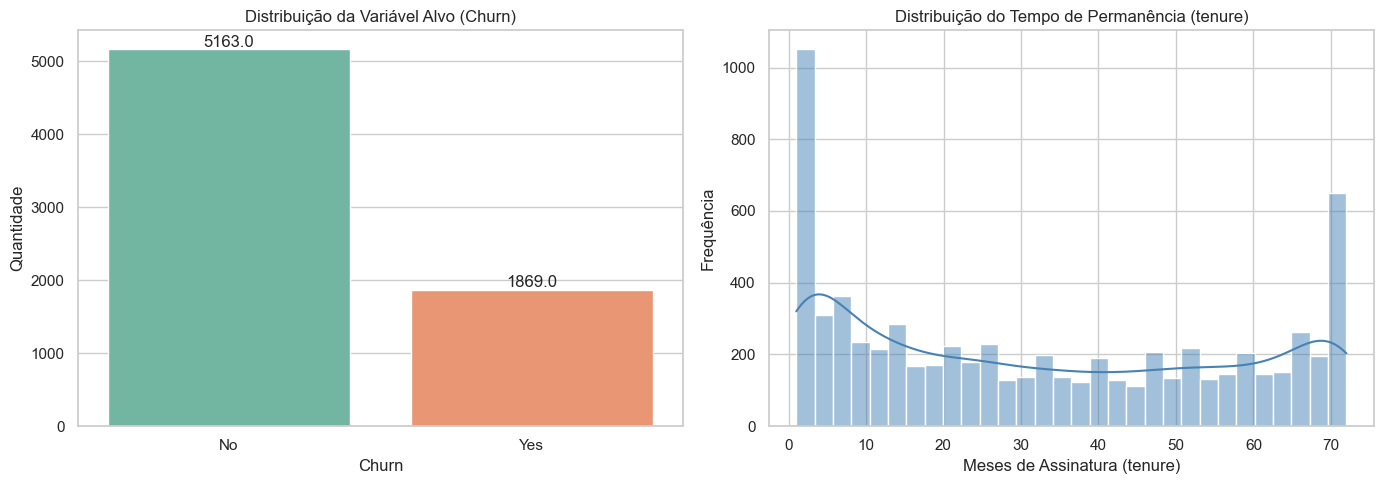


Taxa de Churn Atual: 26.58%
Taxa de Retenção Atual: 73.42%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribuição da Variável Alvo 'Churn'
sns.countplot(data=df, x='Churn', ax=axes[0], hue='Churn', palette='Set2', legend=False)
axes[0].set_title('Distribuição da Variável Alvo (Churn)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Quantidade')

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Histograma do Tempo de Permanência 'tenure'
sns.histplot(data=df, x='tenure', bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribuição do Tempo de Permanência (tenure)')
axes[1].set_xlabel('Meses de Assinatura (tenure)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

# 3. Cálculo da taxa de Churn Atual
churn_rate = (df['Churn'].value_counts(normalize=True).get('Yes', 0)) * 100
print(f"\nTaxa de Churn Atual: {churn_rate:.2f}%")
print(f"Taxa de Retenção Atual: {100 - churn_rate:.2f}%")

## 4. Análise Bivariada (Feature vs Target)

Nesta seção, exploramos como as principais variáveis categóricas de serviços e contratos interagem com o `Churn` através de gráficos de barras empilhadas (proporção).
Também calculamos a correlação de Spearman entre o tempo de casa (`tenure`) e o `Churn` (mapeado para numérico).

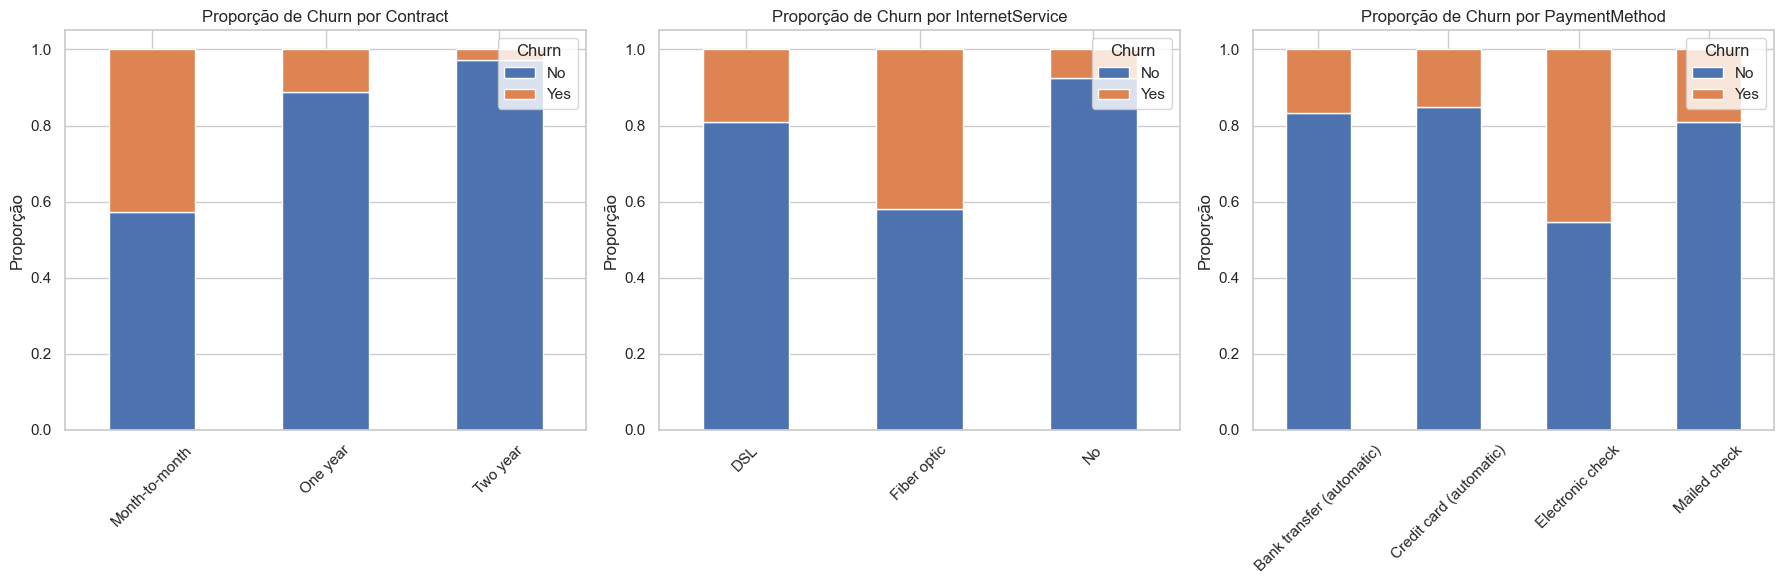


Correlação de Spearman entre 'tenure' e 'Churn': -0.3697 (p-value: 1.2904e-226)
Obs: Valores negativos indicam que quanto maior o tempo de casa ('tenure'), menor a probabilidade de Churn.


In [5]:
import scipy.stats as stats

features_categoricas = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(features_categoricas):
    # Calcula a proporção cruzada entre a feature e o Churn
    crosstab = pd.crosstab(df[col], df['Churn'], normalize='index')
    # Plota gráfico de barras empilhadas
    crosstab.plot(kind='bar', stacked=True, ax=axes[i], color=['#4C72B0', '#DD8452'])
    axes[i].set_title(f'Proporção de Churn por {col}')
    axes[i].set_ylabel('Proporção')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn', loc='upper right')

plt.tight_layout()
plt.show()

# Correlação de Spearman entre 'tenure' e 'Churn'
# Mapear Churn para numérico temporariamente para o cálculo
churn_numeric = df['Churn'].map({'Yes': 1, 'No': 0})
corr_spearman, p_value = stats.spearmanr(df['tenure'], churn_numeric)
print(f"\nCorrelação de Spearman entre 'tenure' e 'Churn': {corr_spearman:.4f} (p-value: {p_value:.4e})")
print("Obs: Valores negativos indicam que quanto maior o tempo de casa ('tenure'), menor a probabilidade de Churn.")

## 5. Preparação para Baselines (Pipeline Scikit-Learn)

Para garantir que as categorias não sejam diluídas e para construir uma fundação sólida para a modelagem (Baseline e MLP), vamos estruturar um `ColumnTransformer` que:
- Imputa valores nulos (`SimpleImputer`) e padroniza (`StandardScaler`) as variáveis numéricas.
- Aplica `OneHotEncoder` nas variáveis categóricas.
- Converte o resultado de volta para um DataFrame com nomes de colunas extraídos via `get_feature_names_out`.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separando as features por tipo
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in df.columns if col not in num_features and col != 'Churn']

# 1 e 3. Pipeline para numéricas: Imputação + StandardScaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Prevenção contra novos NaNs
    ('scaler', StandardScaler())
])

# 2. Pipeline para categóricas: OneHotEncoder(drop='first')
cat_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# Unindo tudo no ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop'
)

# Preparando os dados X e o alvo y
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0}) # Alvo mapeado para binário numérico

# Aplicando a transformação no dataset
X_processed_array = preprocessor.fit_transform(X)

# 4. Extraindo o nome das colunas e gerando o DataFrame Final
feature_names = preprocessor.get_feature_names_out()
X_processed = pd.DataFrame(X_processed_array, columns=feature_names)

print(f"Shape original do X: {X.shape}")
print(f"Shape do X processado (após OHE): {X_processed.shape}")

X_processed.head()

Shape original do X: (7032, 19)
Shape do X processado (após OHE): (7032, 30)


,num__tenure,num__MonthlyCharges,num__TotalCharges,cat__gender_Male,cat__SeniorCitizen_1,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_No phone service,cat__MultipleLines_Yes,...,cat__StreamingTV_No internet service,cat__StreamingTV_Yes,cat__StreamingMovies_No internet service,cat__StreamingMovies_Yes,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,-1.280248,-1.161694,-0.994194,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.064303,-0.260878,-0.173740,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.239504,-0.363923,-0.959649,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.512486,-0.747850,-0.195248,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.239504,0.196178,-0.940457,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## 6. Modelagem Baseline (Regressão Logística) com MLflow

Nesta seção, estabelecemos um modelo de referência (Baseline) utilizando Regressão Logística com `class_weight='balanced'` para lidar com o desbalanceamento das classes.
Utilizamos o `mlflow` para registrar os parâmetros do experimento, os coeficientes das features mais importantes e a matriz de confusão.

Top 5 Features - Maior Risco de Churn (+):
cat__InternetService_Fiber optic: 1.1411
num__TotalCharges: 0.6076
cat__PaymentMethod_Electronic check: 0.4071
cat__StreamingTV_Yes: 0.3883
cat__StreamingMovies_Yes: 0.3720

Top 5 Features - Menor Risco de Churn (-):
cat__PhoneService_Yes: -0.3701
num__MonthlyCharges: -0.4918
cat__Contract_One year: -0.7880
num__tenure: -1.2566
cat__Contract_Two year: -1.4574


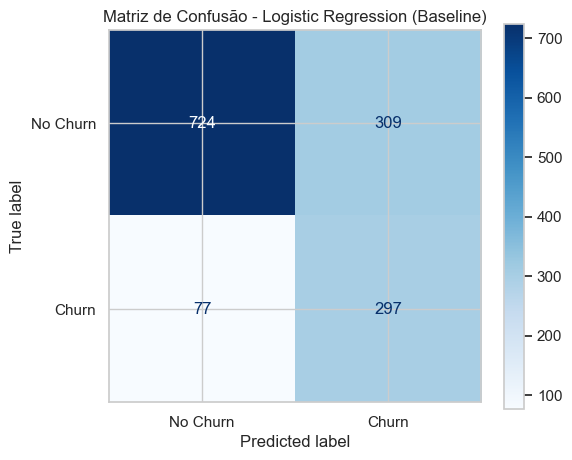


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [8]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import os

# 1. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Configurando o experimento no MLflow
mlflow.set_experiment("Telco_Churn_Baseline")

with mlflow.start_run(run_name="LogisticRegression_Balanced"):
    # 2. Treinamento do Modelo
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    # Log de parâmetros
    mlflow.log_param("model_type", "Logistic Regression")
    mlflow.log_param("class_weight", "balanced")
    
    # Predições
    y_pred = model.predict(X_test)
    
    # 3. Extração e Associação de Coeficientes
    coef_dict = dict(zip(X_processed.columns, model.coef_[0]))
    sorted_coefs = sorted(coef_dict.items(), key=lambda item: item[1], reverse=True)
    
    top_5_positive = sorted_coefs[:5]
    top_5_negative = sorted_coefs[-5:]
    
    print("Top 5 Features - Maior Risco de Churn (+):")
    for feat, coef in top_5_positive:
        print(f"{feat}: {coef:.4f}")
        mlflow.log_metric(f"coef_pos_{feat}", coef)
        
    print("\nTop 5 Features - Menor Risco de Churn (-):")
    for feat, coef in top_5_negative:
        print(f"{feat}: {coef:.4f}")
        mlflow.log_metric(f"coef_neg_{feat}", coef)
    
    # 4. Geração da Matriz de Confusão e Log como Artefato
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap='Blues')
    plt.title('Matriz de Confusão - Logistic Regression (Baseline)')
    
    # Salva a imagem temporariamente para fazer log no mlflow
    os.makedirs("mlruns_artifacts", exist_ok=True)
    cm_path = "mlruns_artifacts/confusion_matrix.png"
    plt.savefig(cm_path)
    plt.show()
    
    mlflow.log_artifact(cm_path, "plots")
    
    # Log de métricas adicionais (F1, Recall, Precision para Churn=1)
    report = classification_report(y_test, y_pred, output_dict=True)
    mlflow.log_metric("f1_score_churn", report['1']['f1-score'])
    mlflow.log_metric("recall_churn", report['1']['recall'])
    mlflow.log_metric("precision_churn", report['1']['precision'])
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

## 7. Otimização de Threshold e Custo Financeiro

Com o baseline atingindo um F1-Score moderado (~0.61), não basta avaliarmos apenas precisão e recall de forma abstrata. O *ML Canvas* especifica uma análise financeira real ponderando:
- **FN (Falso Negativo)** = Cliente sai sem intervenção (LTV perdido estimado em R$ 500).
- **FP (Falso Positivo)** = Campanha aplicada em quem não ia sair (Custo de marketing estimado em R$ 50).

Nesta seção, calculamos o threshold (ponto de corte de probabilidade de 0.1 a 0.9) que minimiza esse prejuízo total e registramos a análise no MLflow.

Threshold Ótimo: 0.165
Custo Financeiro Mínimo Esperado: R$ 35,850.00


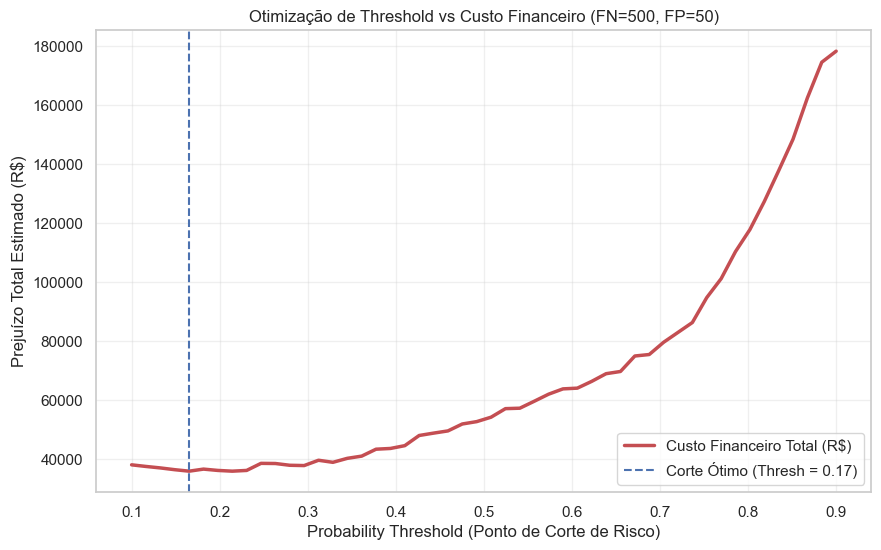

In [9]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import os

# 1. Definição de pesos definidos pela área de negócios (ML Canvas)
COST_FN = 500
COST_FP = 50

# 2. Calculando probabilidades do modelo Baseline (Regressão Logística)
y_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)
custos_totais = []

# 3. Simulação de diferentes Thresholds
for thresh in thresholds:
    # Predição com base no corte atual
    y_pred_thresh = (y_proba >= thresh).astype(int)
    
    # Contagem de FP e FN
    fp = np.sum((y_pred_thresh == 1) & (y_test == 0))
    fn = np.sum((y_pred_thresh == 0) & (y_test == 1))
    
    # Calculando custo
    custo = (fn * COST_FN) + (fp * COST_FP)
    custos_totais.append(custo)

# Identificando o ponto exato de menor custo (otimização de prejuízo)
best_idx = np.argmin(custos_totais)
best_threshold = thresholds[best_idx]
min_cost = custos_totais[best_idx]

print(f"Threshold Ótimo: {best_threshold:.3f}")
print(f"Custo Financeiro Mínimo Esperado: R$ {min_cost:,.2f}")

# Plotando o Gráfico de Curva de Custo
plt.figure(figsize=(10, 6))
plt.plot(thresholds, custos_totais, label='Custo Financeiro Total (R$)', color='#C44E52', linewidth=2.5)
plt.axvline(best_threshold, color='#4C72B0', linestyle='--', label=f'Corte Ótimo (Thresh = {best_threshold:.2f})')
plt.title('Otimização de Threshold vs Custo Financeiro (FN=500, FP=50)')
plt.xlabel('Probability Threshold (Ponto de Corte de Risco)')
plt.ylabel('Prejuízo Total Estimado (R$)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Registro no MLflow
with mlflow.start_run(run_name="Baseline_Financial_Optimization"):
    mlflow.log_param("weight_FN", COST_FN)
    mlflow.log_param("weight_FP", COST_FP)
    mlflow.log_metric("optimal_threshold", best_threshold)
    mlflow.log_metric("min_financial_loss", min_cost)
    
    os.makedirs("mlruns_artifacts", exist_ok=True)
    cost_plot_path = "mlruns_artifacts/cost_vs_threshold.png"
    plt.savefig(cost_plot_path, bbox_inches='tight')
    mlflow.log_artifact(cost_plot_path, "plots")
    
plt.show()

## 8. Feature Engineering e Exportação

Nesta última etapa da EDA, criaremos uma *feature* sintética (`Charges_per_Tenure`) para tentar extrair mais sinal dos dados financeiros.
Em seguida, validaremos o seu poder de separação visualmente e exportaremos o conjunto de dados finalizado e codificado numericamente (Churn = 1/0) para ser utilizado pelo modelo de Redes Neurais (MLP em PyTorch).

C:\Users\humberto.santos\AppData\Local\Temp\ipykernel_3604\3595620369.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Charges_per_Tenure', palette='Set2')


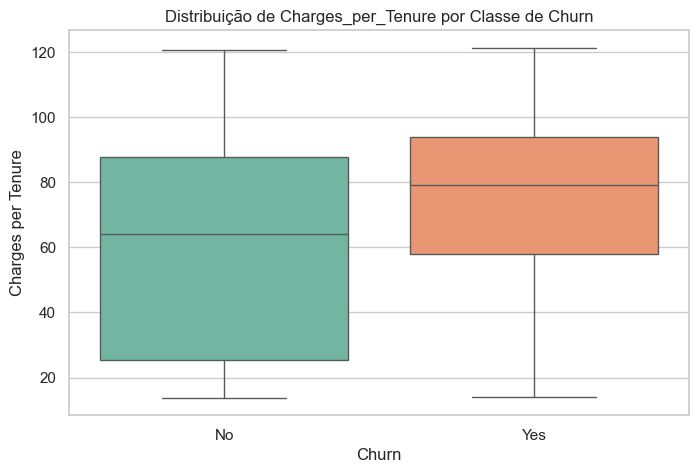


Dataset exportado com sucesso para: ../data/processed/telco_final_for_mlp.csv
Tamanho final do dataset: (7032, 21)
Visualização das primeiras linhas:


,tenure,TotalCharges,Charges_per_Tenure,Churn
0,1,29.85,29.850000,No
1,34,1889.50,55.573529,No
2,2,108.15,54.075000,Yes
3,45,1840.75,40.905556,No
4,2,151.65,75.825000,Yes


In [10]:
import os
import numpy as np

# 1. Criando a nova feature 'Charges_per_Tenure'
# Utilizamos np.where para proteger contra divisão por zero (caso existam clientes com tenure=0)
df['Charges_per_Tenure'] = np.where(df['tenure'] > 0, df['TotalCharges'] / df['tenure'], 0)

# Verificando visualmente a capacidade de separação da nova feature
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='Charges_per_Tenure', palette='Set2')
plt.title('Distribuição de Charges_per_Tenure por Classe de Churn')
plt.xlabel('Churn')
plt.ylabel('Charges per Tenure')
plt.show()

# 2. Codificando o target 'Churn' para 0 e 1 (se ainda não estiver)
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Salvando o dataset finalizado para a etapa de MLP PyTorch
os.makedirs('../data/processed', exist_ok=True)
export_path = '../data/processed/telco_final_for_mlp.csv'
df.to_csv(export_path, index=False)

print(f"\nDataset exportado com sucesso para: {export_path}")
print(f"Tamanho final do dataset: {df.shape}")
print("Visualização das primeiras linhas:")
df[['tenure', 'TotalCharges', 'Charges_per_Tenure', 'Churn']].head()